<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9; border-right: 5px solid #20639b; padding: 8px 18px;">
  <h1 style="color:#173f5f; margin-bottom:4px;">نوت‌بوک 21: کلاسیفیکیشن روی دیتاست معروف Iris</h1>
  <p><b>سطح:</b> متوسط &nbsp; | &nbsp; <b>روش مطالعه:</b> توضیح کوتاه ← اجرای مثال ← تغییر مثال ← حل تمرین</p>
  <h3>هدف‌های یادگیری</h3>
  <ul><li>بارگذاری و آماده‌سازی دیتاست Iris برای یادگیری ماشین</li>
<li>تقسیم داده به Train/Test و استانداردسازی ویژگی‌ها</li>
<li>آموزش و مقایسهٔ چند الگوریتم کلاسیفیکیشن</li>
<li>ارزیابی مدل با Accuracy، Confusion Matrix و Cross-Validation</li></ul>
  <p style="background:#eef6fb; padding:10px; border-radius:8px;">همهٔ سلول‌ها را به‌ترتیب اجرا کنید. برای یادگیری بهتر، مقدار پارامترها را تغییر دهید و نتیجه را پیش‌بینی کنید.</p>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">بارگذاری دیتاست</h2>
  <p>Iris شامل ۱۵۰ نمونه از سه گونهٔ گل زنبق و چهار اندازه‌گیری طول و عرض کاسبرگ و گلبرگ است. این داده داخل scikit-learn قرار دارد و نیازی به دانلود اینترنتی ندارد.</p>
</div>

In [1]:
# Import libraries and load the Iris dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

iris_bundle = load_iris(as_frame=True)
X = iris_bundle.data
y = iris_bundle.target
target_names = iris_bundle.target_names

print("Shape:", X.shape)
print("Target names:", target_names)
X.head()

Shape: (150, 4)
Target names: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">تقسیم داده به Train/Test و استانداردسازی</h2>
  <p>برای ارزیابی منصفانه، داده را به دو بخش آموزش و آزمون تقسیم می‌کنیم. با <code>StandardScaler</code> ویژگی‌ها را استاندارد می‌کنیم تا مدل‌هایی مانند SVM و KNN عملکرد بهتری داشته باشند.</p>
</div>

In [2]:
# Split into train/test sets and scale the features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train.shape, " Test size:", X_test.shape)

Train size: (120, 4)  Test size: (30, 4)


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">تعریف مدل‌های کلاسیفیکیشن</h2>
  <p>شش الگوریتم رایج کلاسیفیکیشن را برای مقایسه انتخاب می‌کنیم: Logistic Regression، KNN، Decision Tree، Random Forest، SVM و Naive Bayes.</p>
</div>

In [3]:
# Define the classification models to compare
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf", probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
}

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">آموزش و ارزیابی هر مدل</h2>
  <p>هر مدل را روی داده‌های آموزش train و روی داده‌های آزمون ارزیابی می‌کنیم. علاوه بر Accuracy روی Test Set، با ۵-Fold Cross-Validation تخمین پایدارتری از عملکرد به دست می‌آوریم.</p>
</div>

In [4]:
# Train each model and collect evaluation metrics
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)

    cv_scores = cross_val_score(model, scaler.fit_transform(X), y, cv=5)

    results.append({
        "Model": name,
        "Test Accuracy": round(acc, 4),
        "CV Mean Accuracy": round(cv_scores.mean(), 4),
        "CV Std": round(cv_scores.std(), 4),
    })

    print(f"\n=== {name} ===")
    print(f"Test Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=target_names))

results_df = pd.DataFrame(results).sort_values("Test Accuracy", ascending=False).reset_index(drop=True)
results_df


=== Logistic Regression ===
Test Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30


=== KNN ===
Test Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


=== Decision Tree ===
Test Accuracy: 0.9333
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        1

,Model,Test Accuracy,CV Mean Accuracy,CV Std
0,SVM,0.9667,0.9667,0.0211
1,Naive Bayes,0.9667,0.9533,0.0267
2,Logistic Regression,0.9333,0.9600,0.0389
3,KNN,0.9333,0.9600,0.0249
4,Decision Tree,0.9333,0.9533,0.0340
5,Random Forest,0.9000,0.9667,0.0211


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">مقایسه گرافیکی مدل‌ها</h2>
  <p>نمودار میله‌ای دقت هر مدل روی داده‌های آزمون را کنار هم نشان می‌دهد تا مقایسهٔ سریع ممکن باشد.</p>
</div>

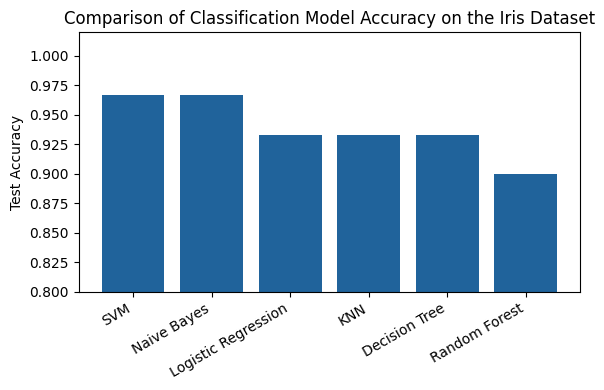

In [8]:
# Compare test accuracy across models
plt.figure(figsize=(6, 4))
plt.bar(results_df["Model"], results_df["Test Accuracy"], color="#20639b")
plt.ylabel("Test Accuracy")
plt.title("Comparison of Classification Model Accuracy on the Iris Dataset")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.8, 1.02)
plt.tight_layout()
plt.show()

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">ماتریس درهم‌ریختگی برای بهترین مدل</h2>
  <p>Confusion Matrix نشان می‌دهد مدل هر کلاس را چند بار درست یا اشتباه پیش‌بینی کرده است. اینجا بهترین مدل بر اساس Test Accuracy را بررسی می‌کنیم.</p>
</div>

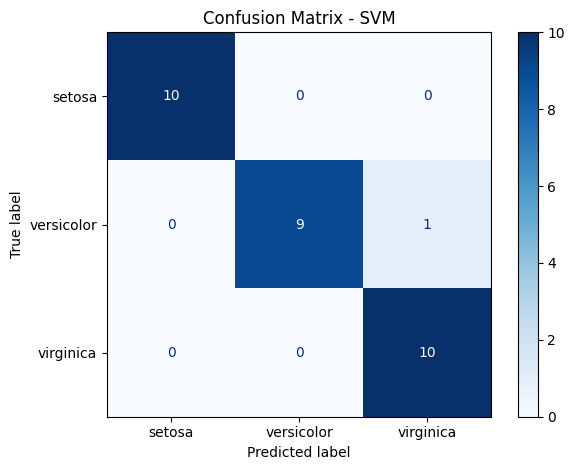

Best model: SVM with Test Accuracy = 0.9667


In [6]:
# Show the confusion matrix of the top-performing model
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.show()

print(f"Best model: {best_model_name} with Test Accuracy = {results_df.iloc[0]['Test Accuracy']}")

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">تمرین کوتاه</h2>
  <div style="background:#fff7df; border:1px solid #f0c36d; padding:12px; border-radius:8px;">با استفاده از <code>GridSearchCV</code> برای مدل SVM بهترین مقدار پارامترهای <code>C</code> و <code>gamma</code> را پیدا کنید و دقت به‌دست‌آمده را با نتیجهٔ اولیهٔ SVM مقایسه کنید.</div>
</div>

<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">پاسخ پیشنهادی</h2>
  <p>ابتدا پاسخ خودتان را بنویسید؛ سپس این سلول را اجرا و مقایسه کنید.</p>
</div>

In [7]:
# Tune SVM hyperparameters with grid search
from sklearn.model_selection import GridSearchCV

param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", 0.1, 0.01, 0.001],
}

grid_search = GridSearchCV(SVC(kernel="rbf", random_state=42), param_grid, cv=5)
grid_search.fit(X_train_scaled, y_train)

tuned_accuracy = accuracy_score(y_test, grid_search.predict(X_test_scaled))

print("Best parameters:", grid_search.best_params_)
print(f"Tuned SVM test accuracy: {tuned_accuracy:.4f}")
print(f"Original SVM test accuracy: {results_df.loc[results_df['Model'] == 'SVM', 'Test Accuracy'].values[0]:.4f}")

Best parameters: {'C': 1, 'gamma': 0.1}
Tuned SVM test accuracy: 0.9667
Original SVM test accuracy: 0.9667


<div dir="rtl" style="text-align: right; font-family: Tahoma, Arial, sans-serif; line-height: 1.9;">
  <h2 style="color:#173f5f;">جمع‌بندی</h2>
  <p>دیتاست Iris به دلیل جدایی‌پذیری نسبتاً خوب کلاس‌ها، توسط اکثر الگوریتم‌های کلاسیفیکیشن با دقت بالا قابل پیش‌بینی است. Cross-Validation نسبت به یک Test Set تنها، تخمین پایدارتری از عملکرد واقعی مدل ارائه می‌دهد و Hyperparameter Tuning می‌تواند دقت را کمی بیشتر بهبود دهد. گام بعدی می‌تواند تکرار همین روند روی دیتاست‌های معروف دیگر مانند Wine یا Breast Cancer باشد.</p>
</div>